# 01 · Schema Overview

**Week 1 Goal**: load every raw dataset, print shape / dtypes / null counts / sample rows, and capture findings into `docs/data_dictionary.md`.

Do **not** commit notebook outputs (handled by `nbstripout` in pre-commit, or strip manually before commit).

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import pandas as pd

# Visualize grant size distributions
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)

# Resolve repo root
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / 'data' / 'processed').exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
PROCESSED_DIR = REPO_ROOT / 'data' / 'processed'
assert PROCESSED_DIR.exists(), f'data/processed folder not found from {Path.cwd()}'
print('Repo root:', REPO_ROOT)
print('Processed data dir:', PROCESSED_DIR)
print('Available parquet files:', sorted(p.name for p in PROCESSED_DIR.glob('*.parquet')))

Repo root: d:\Projects\northeastern_visualization
Processed data dir: d:\Projects\northeastern_visualization\data\processed
Available parquet files: ['extra_neu_abstracts.parquet', 'faculty.parquet', 'faculty_grants.parquet', 'faculty_id_lookup.parquet', 'faculty_missing_metadata.parquet', 'grant_faculty.parquet', 'grant_orphan_recovery.parquet', 'grant_orphaned_abstracts.parquet', 'grant_text.parquet', 'grants.parquet', 'personid_to_faculty.parquet', 'topic_assignments.parquet']


In [2]:
# Load cleaned, normalized Parquet tables from Week 3 pipeline
faculty = pd.read_parquet(PROCESSED_DIR / 'faculty.parquet')
grants = pd.read_parquet(PROCESSED_DIR / 'grants.parquet')
faculty_grants = pd.read_parquet(PROCESSED_DIR / 'faculty_grants.parquet')
# Abstracts merged into grants; orphans (non-NEU) in separate file
grant_orphaned_abstracts = pd.read_parquet(PROCESSED_DIR / 'grant_orphaned_abstracts.parquet')

# Create a 'ri' dataframe by merging grants + faculty_grants for compatibility with existing analysis code
ri = faculty_grants.merge(grants, on='grant_id', how='left')

print("Loaded tables:")
print(f"  faculty:         {faculty.shape}")
print(f"  grants:          {grants.shape}")
print(f"  faculty_grants:   {faculty_grants.shape}")
print(f"  grant_orphaned_abstracts:      {grant_orphaned_abstracts.shape}")
print(f"  ri (merged):     {ri.shape} — compatible with existing analysis\n")
print("Data is clean, normalized, and ready for analysis.")
print("\nColumn names in ri:")
print(list(ri.columns))

Loaded tables:
  faculty:         (2247, 12)
  grants:          (2676, 24)
  faculty_grants:   (3144, 9)
  grant_orphaned_abstracts:      (5095, 22)
  ri (merged):     (3144, 32) — compatible with existing analysis

Data is clean, normalized, and ready for analysis.

Column names in ri:
['faculty_id', 'faculty_name', 'grant_id', 'is_pi', 'is_copi', 'source', 'hire_date', 'grant_startdate', 'neu_status', 'grantname', 'agencycode', 'agencyname', 'agencygrantid', 'totaldollars', 'dollarsperyear', 'durationinyears', 'startdate', 'enddate', 'awarddate', 'startdateyear', 'countrycode', 'isgovernment', 'isresearch', 'pi_names_available', 'db_coverage', 'copi_available', 'title_from_abstract', 'abstract', 'funding_status', 'type_of_funding', 'funding_source', 'abstract_source']


## Data Processing Note

**This notebook now loads cleaned, normalized Parquet data** from the Week 3 pipeline (`src/build_dataset.py`).

All raw xlsx files have been:
- Cleaned (100% null columns dropped, trailing spaces removed)
- Normalized (categorical values standardized, dtypes coerced)
- Deduplicated (grant-level rows are unique; faculty rows are unique)
- Validated (join keys confirmed, date ranges checked)

The `ri` dataframe is a merged version of `faculty_grants` + `grants` for backward compatibility with existing analysis code.

**To update data:** Run `python src/build_dataset.py` after any data refresh; all notebooks will automatically pick up cleaned tables.

In [3]:
# Helper function for exploratory data profiling (optional, not used in current analysis)
def profile(df: pd.DataFrame, label: str) -> None:
    """Print comprehensive data profile for a DataFrame."""
    print('=' * 80)
    print(f'{label}  —  shape={df.shape}')
    print('=' * 80)
    print('\n--- dtypes ---')
    print(df.dtypes.to_string())
    print('\n--- null counts (non-zero only) ---')
    nulls = df.isna().sum()
    print(nulls[nulls > 0].sort_values(ascending=False).to_string() or '(none)')
    print('\n--- head(5) ---')
    display(df.head(5))
    print('\n--- describe(include="all") ---')
    display(df.describe(include='all').T)

## Top 10 faculty earners by total grant dollars

Source: `ri_matches_grants_2026` (canonical structured grants table). Each grant is split across faculty rows; to avoid double-counting a multi-PI grant, we deduplicate to one `(grant_id, AAUID)` row and then sum `totaldollars` per faculty member. Co-PIs share full credit for the grant they were attached to.


## Schema of Cleaned Tables

**faculty:** College/department roster with normalized ranks  
**grants:** Deduplicated grant-level data (one row per grant_id)  
**faculty_grants:** Long-form grant × faculty relationships (PI/co-PI flags)  
**ri:** Merged view of faculty_grants + grants (backward-compatible for analysis)



In [4]:
# Data is already loaded from Parquet in cell 3 as 'ri'
# Top 10 faculty earners by total grant dollars

# Deduplicate on grant + faculty combination
ri_dedup = ri[['grant_id', 'faculty_id', 'faculty_name', 'totaldollars', 'is_copi', 'startdateyear']].drop_duplicates(subset=['grant_id', 'faculty_id'])

# Aggregate by faculty
top10 = (
    ri_dedup.groupby(['faculty_id', 'faculty_name'], as_index=False)
    .agg(
        total_dollars=('totaldollars', 'sum'),
        n_grants=('grant_id', 'nunique'),
        n_as_copi=('is_copi', 'sum'),
        first_year=('startdateyear', 'min'),
        last_year=('startdateyear', 'max')
    )
    .sort_values('total_dollars', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top10['total_dollars'] = top10['total_dollars'].map(lambda v: f'${v:,.0f}')
top10

,faculty_id,faculty_name,total_dollars,n_grants,n_as_copi,first_year,last_year
0,1793665,"MELODIA, TOMMASO","$91,387,201",40,13,2010.0,2025.0
1,141504,"ALSHAWABKEH, AKRAM N","$87,619,945",19,5,2001.0,2020.0
2,148962,"MAKRIYANNIS, ALEXANDROS","$61,984,392",25,2,2004.0,2022.0
3,1383874,"LEVINE, HERBERT","$47,122,908",36,7,2001.0,2025.0
4,148351,"LEWIS, KIM","$46,153,290",21,1,2004.0,2022.0
5,2474499,"QUARANTA, VITO","$45,827,727",14,1,2004.0,2018.0
6,2108075,"WINSLOW, RAI LESTER","$40,300,548",21,3,2005.0,2020.0
7,951814,"ABUR, ALI","$38,745,428",8,1,2005.0,2024.0
8,148296,"KAELI, DAVID R","$33,796,673",33,15,1995.0,2024.0
9,2980311,"BRONICH, TATIANA KARPOVNA","$33,482,077",12,2,2005.0,2018.0


## Faculty Distribution

In [5]:
# Faculty data already loaded from Parquet in cell 3 as 'faculty'
# Group by college

by_college = (
    faculty.groupby('superior_academic_unit', as_index=False)
    .agg(n_faculty=('faculty_id', 'nunique'))
    .sort_values('n_faculty', ascending=False)
    .reset_index(drop=True)
)

total = by_college['n_faculty'].sum()
by_college['pct_of_total'] = (by_college['n_faculty'] / total * 100).apply(lambda x: f'{x:.1f}%')

print(f'Total faculty: {total:,}  across {len(by_college)} colleges')
by_college

Total faculty: 2,247  across 17 colleges


,superior_academic_unit,n_faculty,pct_of_total
0,College of Engineering,356,15.8%
1,College of Science,332,14.8%
2,College of Social Sciences and Humanities,304,13.5%
3,Bouvé College of Health Sciences,269,12.0%
4,D'Amore-McKim School of Business,215,9.6%
5,Khoury College of Computer Sciences,210,9.3%
6,"College of Arts, Media and Design",210,9.3%
7,Northeastern University London,126,5.6%
8,College of Professional Studies,110,4.9%
9,School of Law,58,2.6%


In [6]:
# Academic Rank distribution (using already-loaded faculty data)
by_rank = (
    faculty.groupby('academic_rank', as_index=False)
    .agg(n_faculty=('faculty_id', 'nunique'))
    .sort_values('n_faculty', ascending=False)
    .reset_index(drop=True)
)

total = by_rank['n_faculty'].sum()
by_rank['pct_of_total'] = (by_rank['n_faculty'] / total * 100).apply(lambda x: f'{x:.1f}%')

print(f'Total faculty: {total:,}  across {len(by_rank)} ranks')
by_rank

Total faculty: 2,232  across 10 ranks


,academic_rank,n_faculty,pct_of_total
0,Professor,534,23.9%
1,Assistant Professor,387,17.3%
2,Associate Professor,355,15.9%
3,Associate Teaching Professor,251,11.2%
4,Assistant Teaching Professor,233,10.4%
5,Teaching Professor,188,8.4%
6,Other,156,7.0%
7,Visiting / Adjunct,47,2.1%
8,Research Professor,46,2.1%
9,Lecturer,35,1.6%


In [7]:
# College Breakdown (by Superior Academic Unit and Track Type)
# Pivot: Academic Unit × Academic Track Type
pivot_unit = faculty.pivot_table(
    index='superior_academic_unit',
    columns='academic_track_type',
    values='faculty_id',
    aggfunc='nunique',
    fill_value=0,
)
pivot_unit['TOTAL'] = pivot_unit.sum(axis=1)
pivot_unit = pivot_unit.sort_values('TOTAL', ascending=False)
pivot_unit.index.name = 'academic_unit'
pivot_unit.columns.name = None

# Same column ordering: tenure-related first, then others, then TOTAL
cols = [c for c in pivot_unit.columns if c != 'TOTAL']
tenure_cols = sorted([c for c in cols if 'tenure' in str(c).lower()])
other_cols  = sorted([c for c in cols if 'tenure' not in str(c).lower()])
pivot_unit = pivot_unit[tenure_cols + other_cols + ['TOTAL']]

print(f'{len(pivot_unit)} academic units\n')
pivot_unit

17 academic units



,Non-Tenure,Tenure Track,Research Only,Teaching Only,Teaching and Research,Teaching and Scholarship,Visiting Lecturers,TOTAL
academic_unit,,,,,,,,
College of Engineering,149,207,0,0,0,0,0,356
College of Science,143,172,0,2,2,8,5,332
College of Social Sciences and Humanities,122,152,0,0,0,4,26,304
Bouvé College of Health Sciences,174,87,0,0,0,0,8,269
D'Amore-McKim School of Business,122,93,0,0,0,0,0,215
Khoury College of Computer Sciences,129,80,0,0,0,0,1,210
"College of Arts, Media and Design",100,103,0,0,0,0,7,210
Northeastern University London,0,0,4,8,45,69,0,126
College of Professional Studies,106,1,0,0,0,0,3,110


In [8]:
# Pivot: Academic Unit × Academic Track Type
pivot_unit = faculty.pivot_table(
    index='academic_unit',
    columns='academic_track_type',
    values='faculty_id',
    aggfunc='nunique',
    fill_value=0,
)
pivot_unit['TOTAL'] = pivot_unit.sum(axis=1)
pivot_unit = pivot_unit.sort_values('TOTAL', ascending=False)
pivot_unit.index.name = 'academic_unit'
pivot_unit.columns.name = None

# Same column ordering: tenure-related first, then others, then TOTAL
cols = [c for c in pivot_unit.columns if c != 'TOTAL']
tenure_cols = sorted([c for c in cols if 'tenure' in str(c).lower()])
other_cols  = sorted([c for c in cols if 'tenure' not in str(c).lower()])
pivot_unit = pivot_unit[tenure_cols + other_cols + ['TOTAL']]

print(f'{len(pivot_unit)} academic units\n')
with pd.option_context('display.max_rows', None):
    display(pivot_unit)


91 academic units



,Non-Tenure,Tenure Track,Research Only,Teaching Only,Teaching and Research,Teaching and Scholarship,Visiting Lecturers,TOTAL
academic_unit,,,,,,,,
Khoury College of Computer Sciences,129,80,0,0,0,0,1,210
College of Professional Studies,106,1,0,0,0,0,3,110
Electrical and Computer Engineering,23,75,0,0,0,0,0,98
College of Engineering,82,0,0,0,0,0,0,82
Mechanical and Industrial Engineering,25,56,0,0,0,0,0,81
Art and Design,40,38,0,0,0,0,1,79
Physics,17,49,0,0,0,0,0,66
English,33,20,0,0,0,0,12,65
School of Law,22,33,0,0,0,0,3,58


Matched faculty  : 557 of 2,247 (24.8% of roster)
Total grant-rows : 3,076

College-level grant summary:


,n_faculty_total,n_with_grants,pct_with_grants,n_grants,total_dollars,avg_grants_per_person,avg_dollars_per_person,total_copi
superior_academic_unit,,,,,,,,
College of Engineering,356,172,48.3,1149,955332019.0,6.680233,5554256.0,294
College of Science,332,142,42.8,868,683530322.0,6.112676,4813594.0,188
Khoury College of Computer Sciences,210,68,32.4,422,329848931.0,6.205882,4850720.0,109
Bouvé College of Health Sciences,269,66,24.5,292,391758688.0,4.424242,5935738.0,38
College of Social Sciences and Humanities,304,50,16.4,142,91106859.0,2.840000,1822137.0,45
Engineering,10,10,100.0,86,93277703.0,8.600000,9327770.0,38
"College of Arts, Media and Design",210,24,11.4,61,40331454.0,2.541667,1680477.0,30
School of Law,58,7,12.1,12,9317837.0,1.714286,1331120.0,4
College of science,2,2,100.0,11,21691597.0,5.500000,10845798.0,2


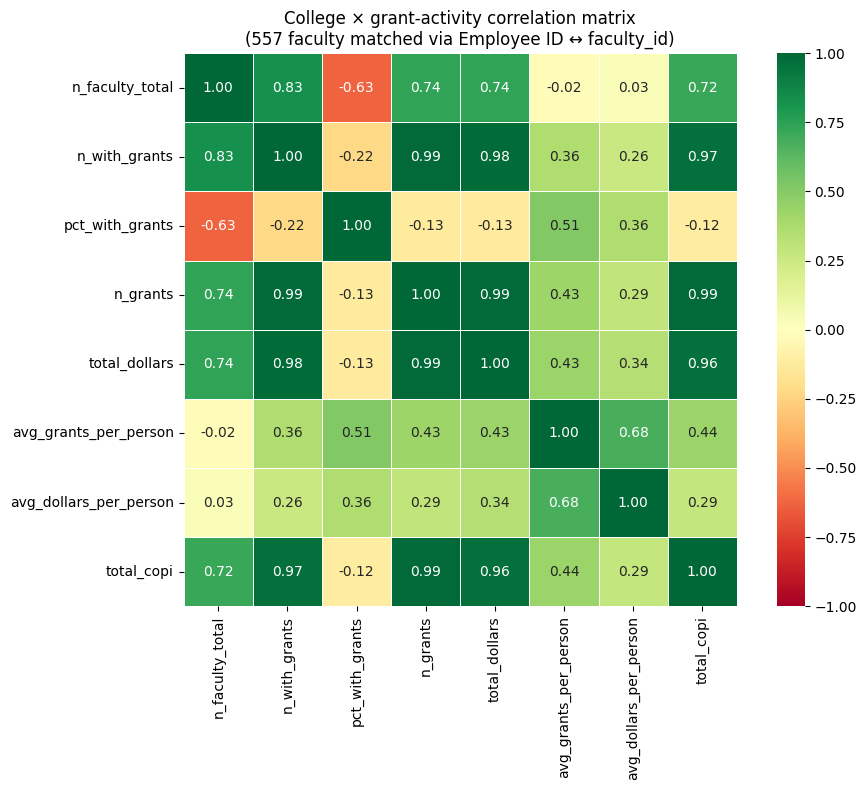

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Data already loaded from Parquet in cell 3
# ── Join: Employee ID ↔ faculty_id ──────────────────────────────────────
ri_dedup = ri.drop_duplicates(subset=['grant_id', 'faculty_id'])

per_person = (
    ri_dedup.groupby('faculty_id', as_index=False, observed=True)
            .agg(
                n_grants           = ('grant_id',      'nunique'),
                total_dollars      = ('totaldollars',  'sum'),
                n_copi             = ('is_copi',        'sum'),
                n_agencies         = ('agencyname',   'nunique'),
                year_span          = ('startdateyear', lambda x: int(x.max() - x.min() + 1) if x.notna().any() else 0),
            )
)

merged = faculty.merge(
    per_person,
    left_on='faculty_id',
    right_on='faculty_id',
    how='inner',
)

n_matched  = merged['faculty_id'].nunique()
n_total    = faculty['faculty_id'].nunique()
n_grants   = merged['n_grants'].sum()
print(f"Matched faculty  : {n_matched:,} of {n_total:,} ({n_matched/n_total*100:.1f}% of roster)")
print(f"Total grant-rows : {int(n_grants):,}\n")

# ── College-level grant summary ───────────────────────────────────────────────
faculty_counts = (
    faculty.groupby('superior_academic_unit', observed=True)['faculty_id']
           .nunique()
           .rename('n_faculty_total')
)

college_stats = (
    merged.groupby('superior_academic_unit', observed=True)
          .agg(
              n_with_grants         = ('faculty_id',   'nunique'),
              n_grants              = ('n_grants',      'sum'),
              total_dollars         = ('total_dollars', 'sum'),
              avg_grants_per_person = ('n_grants',      'mean'),
              total_copi            = ('n_copi',        'sum'),
          )
          .join(faculty_counts)
)
college_stats['pct_with_grants'] = (
    college_stats['n_with_grants'] / college_stats['n_faculty_total'] * 100
).round(1)
college_stats['avg_dollars_per_person'] = (
    college_stats['total_dollars'] / college_stats['n_with_grants']
).round(0)
college_stats = college_stats.sort_values('n_grants', ascending=False)

print("College-level grant summary:")
display(college_stats[[
    'n_faculty_total', 'n_with_grants', 'pct_with_grants',
    'n_grants', 'total_dollars', 'avg_grants_per_person',
    'avg_dollars_per_person', 'total_copi',
]])

# ── Correlation matrix ────────────────────────────────────────────────────────
corr_cols = [
    'n_faculty_total', 'n_with_grants', 'pct_with_grants',
    'n_grants', 'total_dollars', 'avg_grants_per_person',
    'avg_dollars_per_person', 'total_copi',
]
corr = college_stats[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='RdYlGn',
    vmin=-1, vmax=1, center=0,
    linewidths=0.5, square=True, ax=ax,
)
ax.set_title(
    f'College × grant-activity correlation matrix\n'
    f'({n_matched:,} faculty matched via Employee ID ↔ faculty_id)',
    fontsize=12,
)
plt.tight_layout()
plt.show()

Total PI ↔ co-PI pairs across all grants: 436
Unique grants with ≥1 co-PI            : 290

After mapping:
  PI missing college   : 0 of 158 unique PIs
  co-PI missing college: 0 of 211 unique co-PIs

Top 20 PI ↔ co-PI collaboration pairs (with grant details):


,pi_name,pi_college,copi_name,copi_college,n_grants,grant_titles (unique grants seperated by |),agencies
0,"ONDRECHEN, MARY JO",College of Science,"BEUNING, PENNY J",College of Science,7,Are Enzyme Active Sites Built in Multiple Layers? | Chem...,National Science Foundation
1,"WOOD, DARIEN",College of Science,"BARBERIS, EMANUELA",College of Science,6,Experimental High Energy Particle Physics | Experimental...,National Science Foundation
2,"ZEID, IBRAHIM",College of Engineering,"DUGGAN, CLAIRE",Engineering,5,BPE-Track 2: Modernizing Education: Using AI to Improve ...,National Science Foundation
3,"NATH, PRAN",College of Science,"TAYLOR, TOMASZ R",College of Science,5,Research in Elementary Particle Theory | Research in Ele...,National Science Foundation
4,"SZNAIER, MARIO",College of Engineering,"CAMPS, OCTAVIA",College of Engineering,5,CPS:Medium: Safe Learning-Enabled Cyberphysical Systems ...,National Science Foundation
...,...,...,...,...,...,...,...
340,"KAMARTHI, SAGAR V",College of Engineering,"ISAACS, JACKIE A",Engineering,1,Developing Integrative Manufacturing and Production Engi...,National Science Foundation
341,"KAELI, DAVID R",College of Engineering,"WANG, YANZHI",College of Engineering,1,MRI: Acquisition of a Heterogeneous Multi-GPU Cluster to...,National Science Foundation
342,"KAELI, DAVID R",College of Engineering,"TIWARI, DEVESH",Engineering,1,MRI: Acquisition of a Heterogeneous Multi-GPU Cluster to...,National Science Foundation
343,"KAELI, DAVID R",College of Engineering,"LIN, XUE",College of Engineering,1,MRI: Acquisition of a Heterogeneous Multi-GPU Cluster to...,National Science Foundation



Pairs with both sides matched to a college: 436 of 436 (100.0%)



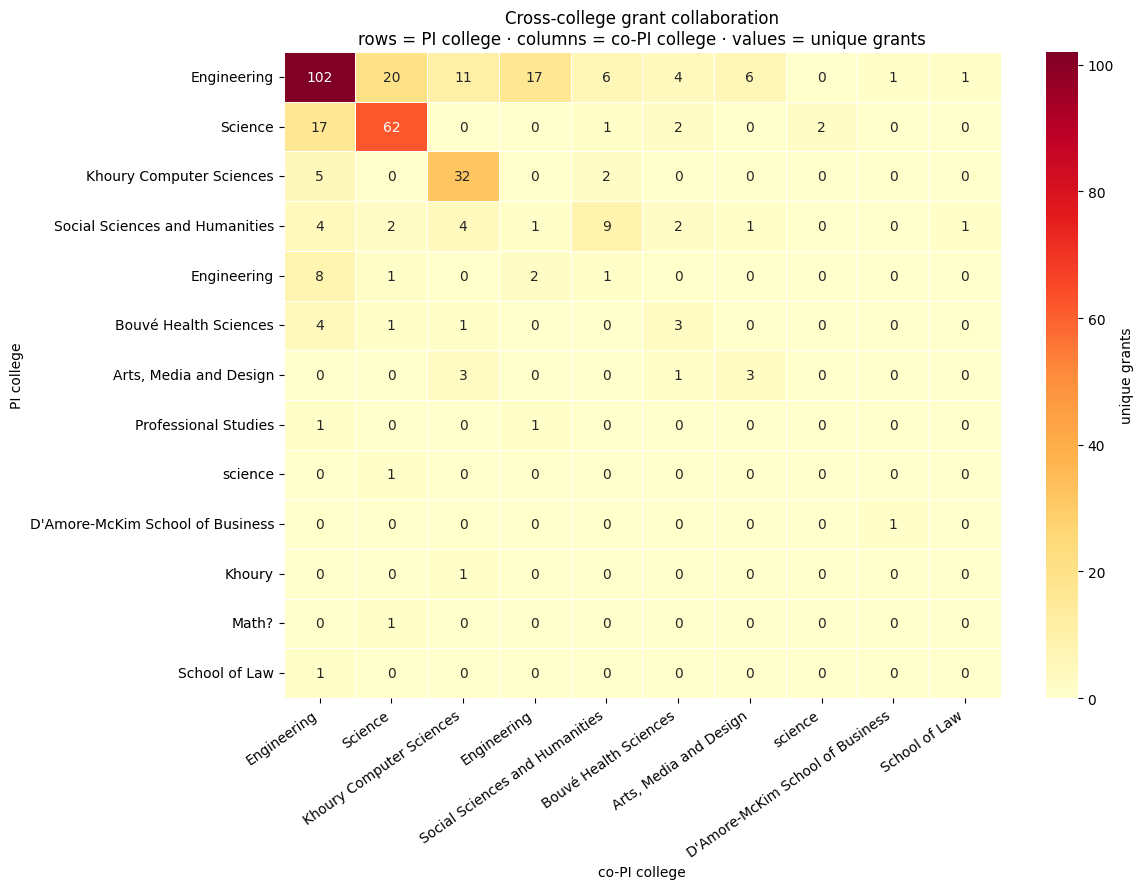

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Data already loaded from Parquet in cell 3
ri_dedup = ri.drop_duplicates(subset=['grant_id', 'faculty_id'])

# ── 1. Build PI ↔ co-PI pairs per grant ──────────────────────────────────────
pi_rows   = ri_dedup[ri_dedup['is_copi'] == 0][['grant_id', 'faculty_id', 'faculty_name']].rename(
    columns={'faculty_id': 'pi_id', 'faculty_name': 'pi_name'})
copi_rows = ri_dedup[ri_dedup['is_copi'] == 1][['grant_id', 'faculty_id', 'faculty_name']].rename(
    columns={'faculty_id': 'copi_id', 'faculty_name': 'copi_name'})

pairs = pi_rows.merge(copi_rows, on='grant_id')
print(f"Total PI ↔ co-PI pairs across all grants: {len(pairs):,}")
print(f"Unique grants with ≥1 co-PI            : {pairs['grant_id'].nunique():,}\n")

# ── 1b. Add grant details (title and funding source) ─────────────────────────
grant_details = ri_dedup[['grant_id', 'grantname', 'agencyname']].drop_duplicates(subset=['grant_id'])
pairs = pairs.merge(grant_details, on='grant_id', how='left')

# ── 2. Enrich each person with college via Employee ID ↔ faculty_id ──────
id_to_college = (
    faculty.dropna(subset=['faculty_id'])
           .set_index('faculty_id')['superior_academic_unit']
           .to_dict()
)

pairs['pi_college']   = pairs['pi_id'].map(id_to_college)
pairs['copi_college'] = pairs['copi_id'].map(id_to_college)


print(f"After mapping:")
print(f"  PI missing college   : {pairs['pi_college'].isna().sum()} of {len(pairs.drop_duplicates('pi_id'))} unique PIs")
print(f"  co-PI missing college: {pairs['copi_college'].isna().sum()} of {len(pairs.drop_duplicates('copi_id'))} unique co-PIs\n")

# ── 3. All collaboration pairs (with colleges, grant titles, and agencies) ────
all_pairs = (
    pairs.groupby(['pi_name', 'pi_college', 'copi_name', 'copi_college'], as_index=False, dropna=False)
         .agg(
             n_grants=('grant_id', 'nunique'),
             **{'grant_titles (unique grants seperated by |)': ('grantname', lambda x: ' | '.join(sorted(set(x.dropna()))[:5]) )},  # Top 5 unique titles
             agencies=('agencyname', lambda x: ', '.join(sorted(set(x.dropna()))))
         )
         .sort_values('n_grants', ascending=False)
         .reset_index(drop=True)
)
all_pairs['pi_college']   = all_pairs['pi_college'].astype(str).fillna('(still unmatched)')
all_pairs['copi_college'] = all_pairs['copi_college'].astype(str).fillna('(still unmatched)')
print("Top 20 PI ↔ co-PI collaboration pairs (with grant details):")
with pd.option_context('display.max_rows', 20, 'display.max_colwidth', 60):
    display(all_pairs[['pi_name', 'pi_college', 'copi_name', 'copi_college', 'n_grants', 'grant_titles (unique grants seperated by |)', 'agencies']])

# ── 4. College × college collaboration matrix ─────────────────────────────────
matched = pairs.dropna(subset=['pi_college', 'copi_college'])
n_pairs_matched = len(matched)
n_pairs_total   = len(pairs)
print(f"\nPairs with both sides matched to a college: {n_pairs_matched:,} of {n_pairs_total:,} "
      f"({n_pairs_matched/n_pairs_total*100:.1f}%)\n")

collab_matrix = (
    matched.groupby(['pi_college', 'copi_college'])['grant_id']
           .nunique()
           .unstack(fill_value=0)
)

row_order = collab_matrix.sum(axis=1).sort_values(ascending=False).index
col_order = collab_matrix.sum(axis=0).sort_values(ascending=False).index
collab_matrix = collab_matrix.loc[row_order, col_order]

short = lambda s: s.replace('College of ', '').replace('Northeastern University ', 'NU ')
collab_matrix.index   = [short(c) for c in collab_matrix.index]
collab_matrix.columns = [short(c) for c in collab_matrix.columns]

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    collab_matrix, annot=True, fmt='d', cmap='YlOrRd',
    linewidths=0.4, ax=ax, cbar_kws={'label': 'unique grants'}
)
ax.set_title(
    'Cross-college grant collaboration\n'
    'rows = PI college · columns = co-PI college · values = unique grants',
    fontsize=12,
)
ax.set_xlabel('co-PI college')
ax.set_ylabel('PI college')
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [11]:
# Summary: Unmatched individuals (from collaboration analysis)
# Note: The 'pairs' dataframe was created in the cell above with colleges filled in

# Unique PIs still missing college
unmatched_pis = pairs[pairs['pi_college'].isna()][['pi_id', 'pi_name']].drop_duplicates()
n_unmatched_pi = len(unmatched_pis)

# Unique co-PIs still missing college
unmatched_copis = pairs[pairs['copi_college'].isna()][['copi_id', 'copi_name']].drop_duplicates()
n_unmatched_copi = len(unmatched_copis)

# Total unique faculty in pairs
total_unique_pis = pairs[['pi_id', 'pi_name']].drop_duplicates()
total_unique_copis = pairs[['copi_id', 'copi_name']].drop_duplicates()

print(f"Still unmatched after pipeline mapping:")
print(f"  PIs   : {n_unmatched_pi:,} of {len(total_unique_pis):,} "
      f"({n_unmatched_pi/len(total_unique_pis)*100:.1f}%)")
print(f"  co-PIs: {n_unmatched_copi:,} of {len(total_unique_copis):,} "
      f"({n_unmatched_copi/len(total_unique_copis)*100:.1f}%)")

if n_unmatched_pi > 0 or n_unmatched_copi > 0:
    # Combined unique individuals still unmatched
    all_still_unmatched = pd.concat([
        unmatched_pis.rename(columns={'pi_id': 'id', 'pi_name': 'name'}),
        unmatched_copis.rename(columns={'copi_id': 'id', 'copi_name': 'name'})
    ]).drop_duplicates(subset=['id']).sort_values('name').reset_index(drop=True)
    
    print(f"\nIndividuals still missing college mapping: {len(all_still_unmatched):,}")
    print("\nList of still-unmatched individuals:")
    with pd.option_context('display.max_rows', None):
        display(all_still_unmatched)
else:
    print("\n✓ All individuals successfully mapped to colleges!")

Still unmatched after pipeline mapping:
  PIs   : 0 of 158 (0.0%)
  co-PIs: 0 of 211 (0.0%)

✓ All individuals successfully mapped to colleges!


## College collaboration (inter and intra college collaborations)

In [12]:
# Bipartite Sankey — PI college (left) → co-PI college (right)
import plotly.graph_objects as go

# Long-form flow table from the matrix we already built (using short labels)
flows = (
    collab_matrix.stack()
                 .reset_index()
                 .rename(columns={'pi_college': 'src', 'copi_college': 'dst', 0: 'n_grants'})
)
flows.columns = ['src', 'dst', 'n_grants']
flows = flows[flows['n_grants'] > 0]

# Distinct node IDs for left (PI) and right (co-PI) sides
src_labels = sorted(flows['src'].unique())
dst_labels = sorted(flows['dst'].unique())
left_nodes  = [f'{c}  (PI)'    for c in src_labels]
right_nodes = [f'(co-PI)  {c}' for c in dst_labels]
all_nodes   = left_nodes + right_nodes
node_idx = {n: i for i, n in enumerate(all_nodes)}

# Consistent color per college (regardless of side)
import matplotlib.colors as mc
palette = plt.get_cmap('tab20')
college_colors = {c: mc.to_hex(palette(i % 20)) for i, c in enumerate(sorted(set(src_labels + dst_labels)))}
node_colors = (
    [college_colors[c] for c in src_labels] +
    [college_colors[c] for c in dst_labels]
)

# Link colors: use the PI-side color, semi-transparent
def rgba(hex_color, alpha=0.45):
    r, g, b = [int(hex_color.lstrip('#')[i:i+2], 16) for i in (0, 2, 4)]
    return f'rgba({r},{g},{b},{alpha})'

sources = [node_idx[f'{r.src}  (PI)']    for r in flows.itertuples()]
targets = [node_idx[f'(co-PI)  {r.dst}'] for r in flows.itertuples()]
values  = flows['n_grants'].tolist()
link_colors = [rgba(college_colors[r.src]) for r in flows.itertuples()]

fig = go.Figure(go.Sankey(
    arrangement='snap',
    node=dict(
        label=all_nodes,
        color=node_colors,
        pad=14, thickness=18,
        line=dict(color='rgba(0,0,0,0.4)', width=0.5),
    ),
    link=dict(
        source=sources, target=targets,
        value=values, color=link_colors,
        hovertemplate='%{source.label} → %{target.label}<br>%{value} grants<extra></extra>',
    ),
))
fig.update_layout(
    title=dict(
        text='PI college → co-PI college  (grant collaboration flow)',
        x=0.5, xanchor='center',
    ),
    font=dict(size=11),
    height=650, margin=dict(l=10, r=10, t=70, b=10),
)
fig.show()


## Action items → `docs/data_dictionary.md`

### Questions 

1. **The grants for faculty members list all grants throughout their career** We cannot devise which grants are from their Northeastern career since we do not know when they started at Northeastern

5. **The faculty list does not account for when they were active in Northeastern** Having active time period of faculty member in Northeastern would help evaluate the grant analysis

6. **Focus on aggregrate info research first** Gradual examination of aggregrate trends - do not want to explore research ideas. 

7. **Topic analysis** What kind of research are we doing in Northeastern?

8. **Collaboration between Faculty** Review the coPI between faculty - interdisciplinary collaboration between faculty is important - interdisciplinrity between colleges in Northeastern is very relevant

9. **Correlation Matrix todo** Researchers vs coPI vs colleges.

4. **Who is the wider audience, really?** can mean prospective students, donors, prospective faculty, accreditation visitors, or current NU researchers — each of those wants a different story. If you had to pick the *one* visitor I should design for, who is it?

5. **What is the headline story you'd want this to tell?** I can already see candidates in the data has an explosive growth post-2010 (Khoury alone has 210 faculty now), the NSF-heavy funding mix (2,123 of ~2,670 grants), the concentration of dollars in a small group of mega-PIs (Melodia 40 grants, Levine 36, Kaeli 33). Any you would want to lead with?

6. **Are there stories the data could tell that we should *not* tell?** Like funding inequality by department, by tenure status, by gender (if we ever get that data), or year-over-year declines in specific colleges are all things this dataset can show. I'd rather know now if any of those are no-go zones, vs build a chart and have to kill it in August.

7. **What's missing that you wish we had?** The faculty 2025 roster - lists all faculty but does not distinguish on their current status - is this everyone who has been party of Northeastern or only active 2025 faculty members? Is there a historical faculty roster (with hire/departure dates) I should request? Same question for demographic data — I *do not* want to guess at this; want to know if it exists and whether equity analysis is in scope - or if you would want me to gather this information via scraping their linkedin or personal website information.

8. **What kind of trend are we focusing on?** Creating a time-series chart would show the "trend" on the grants coming in to Northeastern over the years. But what counts as a "trend", and what kind of "trend" do we want to focus on.


## Grant Size Analysis

Distribution of grant amounts across colleges, departments, and individual faculty.

In [13]:
# Grant size distribution by college
# Merge faculty_grants with faculty to get college info, then with grants to get dollar amounts
grant_college = (
    faculty_grants
    .merge(faculty[['faculty_id', 'superior_academic_unit', 'academic_unit']],
           on='faculty_id', how='left')
    .merge(grants[['grant_id', 'totaldollars', 'agencyname', 'agencycode']],
           on='grant_id', how='left')
)

# Aggregate by college (observed=True: only show colleges present in the grant data)
college_funding = (
    grant_college.groupby('superior_academic_unit', as_index=False, observed=True)
    .agg(
        total_funding=('totaldollars', 'sum'),
        mean_grant_size=('totaldollars', 'mean'),
        median_grant_size=('totaldollars', 'median'),
        min_grant_size=('totaldollars', 'min'),
        max_grant_size=('totaldollars', 'max'),
        n_grants=('grant_id', 'nunique'),
        n_faculty=('faculty_id', 'nunique')
    )
    .sort_values('total_funding', ascending=False)
    .reset_index(drop=True)
)

college_funding['avg_funding_per_faculty'] = college_funding['total_funding'] / college_funding['n_faculty']
college_funding['avg_grants_per_faculty'] = college_funding['n_grants'] / college_funding['n_faculty']

# Format currency columns
currency_cols = ['total_funding', 'mean_grant_size', 'median_grant_size', 'min_grant_size', 'max_grant_size', 'avg_funding_per_faculty']
college_funding_display = college_funding.copy()
for col in currency_cols:
    college_funding_display[col] = college_funding_display[col].apply(lambda x: f'${x:,.0f}')
college_funding_display['avg_grants_per_faculty'] = college_funding_display['avg_grants_per_faculty'].apply(lambda x: f'{x:.1f}')

print(f"Grant size distribution across {len(college_funding)} colleges\n")
college_funding_display

Grant size distribution across 15 colleges



,superior_academic_unit,total_funding,mean_grant_size,median_grant_size,min_grant_size,max_grant_size,n_grants,n_faculty,avg_funding_per_faculty,avg_grants_per_faculty
0,College of Engineering,"$955,332,019","$832,171","$400,095",$527,"$38,591,094",1000,172,"$5,554,256",5.8
1,College of Science,"$683,530,322","$787,477","$434,576","$4,000","$16,188,629",777,142,"$4,813,594",5.5
2,Bouvé College of Health Sciences,"$391,758,688","$1,341,639","$532,212","$1,102","$19,399,383",288,66,"$5,935,738",4.4
3,Khoury College of Computer Sciences,"$329,848,931","$785,355","$455,057","$5,000","$16,217,700",382,68,"$4,850,720",5.6
4,Engineering,"$93,277,703","$1,084,624","$385,026","$10,190","$10,000,000",78,10,"$9,327,770",7.8
5,College of Social Sciences and Humanities,"$91,106,859","$641,598","$247,724","$1,565","$16,217,700",127,50,"$1,822,137",2.5
6,"College of Arts, Media and Design","$40,331,454","$661,171","$499,999","$7,900","$3,204,222",56,24,"$1,680,477",2.3
7,College of science,"$21,691,597","$1,971,963","$1,184,496","$282,349","$6,750,000",11,2,"$10,845,798",5.5
8,School of Law,"$9,317,837","$776,486","$196,147","$15,857","$3,242,197",12,7,"$1,331,120",1.7
9,College of Professional Studies,"$5,037,652","$1,259,413","$1,196,433","$377,769","$2,267,017",4,3,"$1,679,217",1.3


In [14]:
# Grant size distribution by department (top 15)
dept_funding = (
    grant_college.groupby('academic_unit', as_index=False, observed=True)
    .agg(
        total_funding=('totaldollars', 'sum'),
        mean_grant_size=('totaldollars', 'mean'),
        median_grant_size=('totaldollars', 'median'),
        n_grants=('grant_id', 'nunique'),
        n_faculty=('faculty_id', 'nunique')
    )
    .sort_values('total_funding', ascending=False)
    .head(15)
    .reset_index(drop=True)
)

dept_funding['avg_funding_per_faculty'] = dept_funding['total_funding'] / dept_funding['n_faculty']

# Format for display
dept_funding_display = dept_funding.copy()
for col in ['total_funding', 'mean_grant_size', 'median_grant_size', 'avg_funding_per_faculty']:
    dept_funding_display[col] = dept_funding_display[col].apply(lambda x: f'${x:,.0f}')

print("Top 15 departments by total grant funding\n")
dept_funding_display

Top 15 departments by total grant funding



,academic_unit,total_funding,mean_grant_size,median_grant_size,n_grants,n_faculty,avg_funding_per_faculty
0,Electrical and Computer Engineering,"$450,667,328","$825,398","$419,900",456,64,"$7,041,677"
1,Khoury College of Computer Sciences,"$329,848,931","$785,355","$455,057",382,68,"$4,850,720"
2,Physics,"$274,718,078","$861,185","$449,999",290,43,"$6,388,793"
3,Pharmaceutical Sciences,"$255,416,573","$1,850,845","$1,198,380",137,16,"$15,963,536"
4,Civil and Environmental Engineering,"$170,191,336","$1,077,160","$301,513",149,22,"$7,735,970"
5,Mechanical and Industrial Engineering,"$162,172,640","$664,642","$399,483",219,45,"$3,603,836"
6,Psychology,"$139,312,561","$1,160,938","$682,869",109,24,"$5,804,690"
7,Bioengineering,"$136,537,327","$996,623","$434,163",136,25,"$5,461,493"
8,Biology,"$111,906,318","$1,153,673","$711,660",94,18,"$6,217,018"
9,Chemistry and Chemical Biology,"$80,971,278","$698,028","$450,000",100,20,"$4,048,564"


In [15]:
# Individual faculty grant size analysis (top 20)
# Deduplicate grant-faculty pairs to avoid double-counting multi-PI grants
grant_college_dedup = grant_college.drop_duplicates(subset=['grant_id', 'faculty_id'])

faculty_funding = (
    grant_college_dedup.groupby('faculty_id', as_index=False, observed=True)
    .agg(
        faculty_name=('faculty_name', 'first'),
        college=('superior_academic_unit', 'first'),
        total_funding=('totaldollars', 'sum'),
        mean_grant_size=('totaldollars', 'mean'),
        median_grant_size=('totaldollars', 'median'),
        n_grants=('grant_id', 'nunique')
    )
    .sort_values('total_funding', ascending=False)
    .head(20)
    .reset_index(drop=True)
)

# Format for display
faculty_funding_display = faculty_funding.copy()
for col in ['total_funding', 'mean_grant_size', 'median_grant_size']:
    faculty_funding_display[col] = faculty_funding_display[col].apply(lambda x: f'${x:,.0f}')

print("Top 20 faculty by total grant funding\n")
faculty_funding_display

Top 20 faculty by total grant funding



,faculty_id,faculty_name,college,total_funding,mean_grant_size,median_grant_size,n_grants
0,1793665,"MELODIA, TOMMASO",College of Engineering,"$91,387,201","$2,284,680","$475,000",40
1,141504,"ALSHAWABKEH, AKRAM N",College of Engineering,"$87,619,945","$4,611,576","$1,091,661",19
2,148962,"MAKRIYANNIS, ALEXANDROS",Bouvé College of Health Sciences,"$61,984,392","$2,479,376","$1,229,796",25
3,1383874,"LEVINE, HERBERT",College of Science,"$47,122,908","$1,308,970","$485,695",36
4,148351,"LEWIS, KIM",College of Science,"$46,153,290","$2,197,776","$1,364,404",21
5,2474499,"QUARANTA, VITO",Bouvé College of Health Sciences,"$45,827,727","$3,273,409","$2,162,503",14
6,2108075,"WINSLOW, RAI LESTER",College of Engineering,"$40,300,548","$1,919,074","$748,819",21
7,951814,"ABUR, ALI",College of Engineering,"$38,745,428","$4,843,178","$342,994",8
8,148296,"KAELI, DAVID R",College of Engineering,"$33,796,673","$1,024,142","$466,000",33
9,2980311,"BRONICH, TATIANA KARPOVNA",Bouvé College of Health Sciences,"$33,482,077","$2,790,173","$1,350,789",12


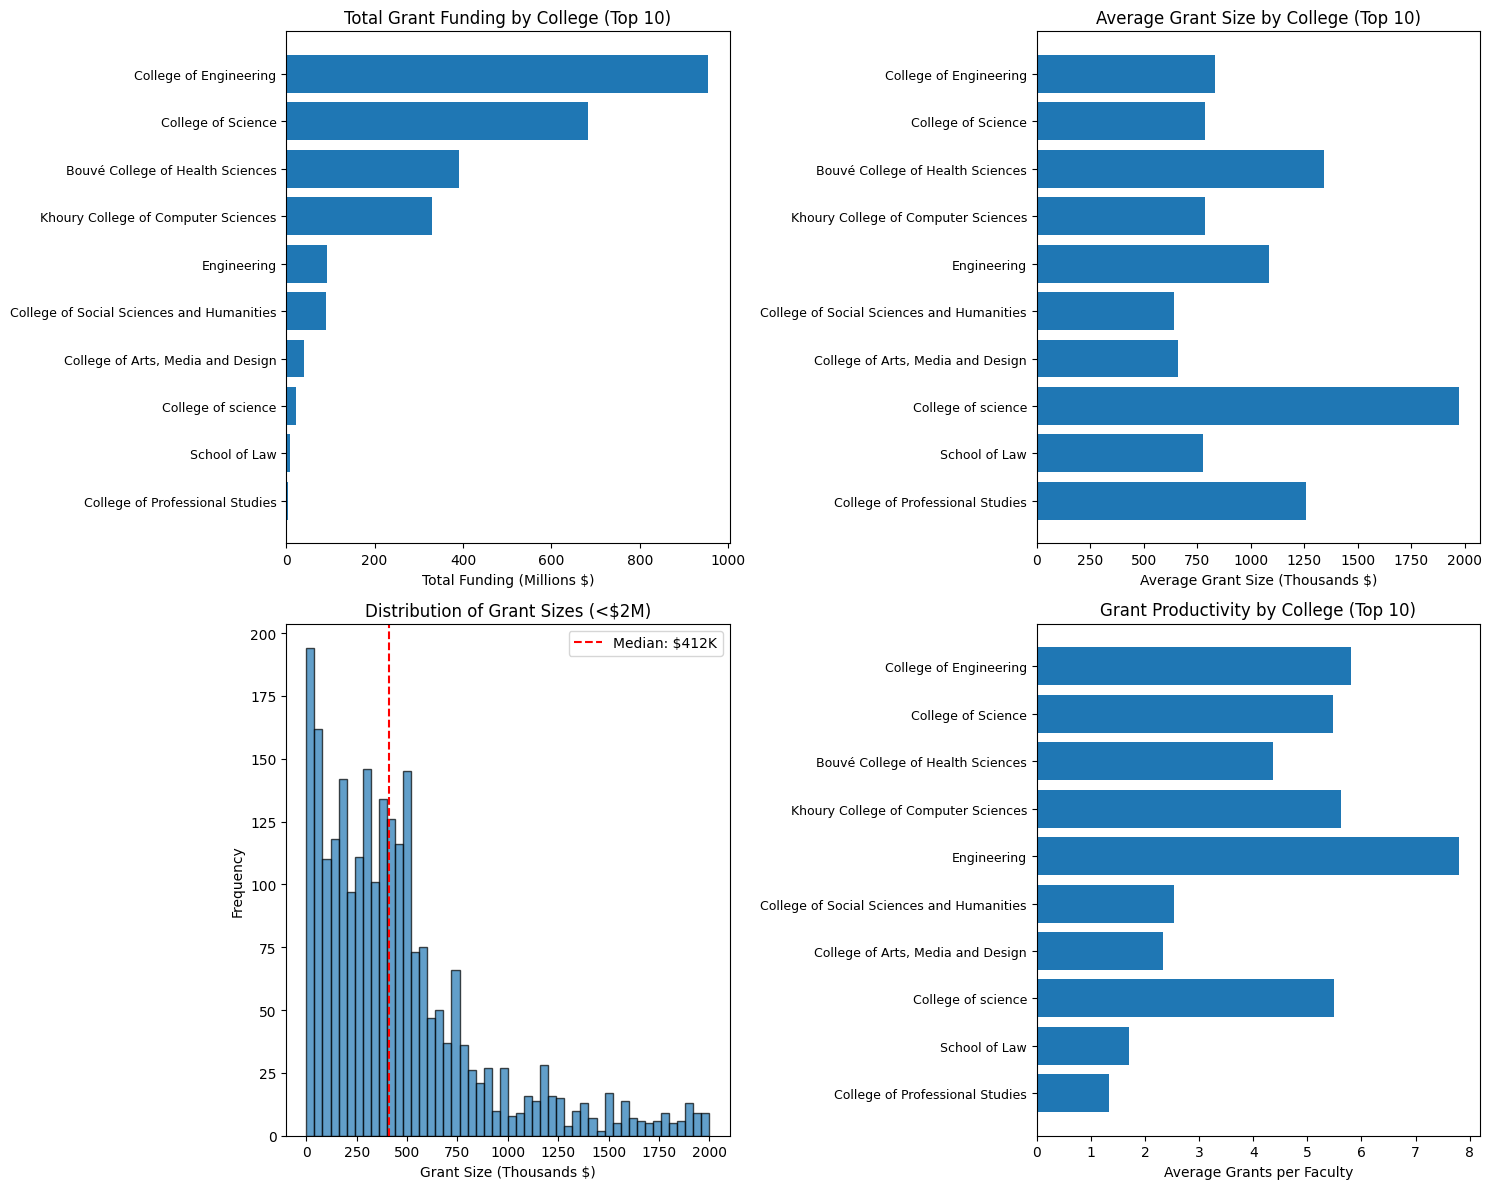


Overall grant statistics:
  Total grants: 2,676
  Total funding: $2,183,457,207
  Mean grant size: $815,941
  Median grant size: $412,028
  Min grant size: $527
  Max grant size: $38,591,094


In [16]:
# Ensure outputs directory exists
outputs_dir = PROCESSED_DIR.parent / 'outputs'
outputs_dir.mkdir(exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Total funding by college (top 10)
top_colleges = college_funding.head(10)
axes[0, 0].barh(range(len(top_colleges)), top_colleges['total_funding'] / 1e6)
axes[0, 0].set_yticks(range(len(top_colleges)))
axes[0, 0].set_yticklabels(top_colleges['superior_academic_unit'], fontsize=9)
axes[0, 0].set_xlabel('Total Funding (Millions $)')
axes[0, 0].set_title('Total Grant Funding by College (Top 10)')
axes[0, 0].invert_yaxis()

# 2. Average grant size by college
axes[0, 1].barh(range(len(top_colleges)), top_colleges['mean_grant_size'] / 1000)
axes[0, 1].set_yticks(range(len(top_colleges)))
axes[0, 1].set_yticklabels(top_colleges['superior_academic_unit'], fontsize=9)
axes[0, 1].set_xlabel('Average Grant Size (Thousands $)')
axes[0, 1].set_title('Average Grant Size by College (Top 10)')
axes[0, 1].invert_yaxis()

# 3. Grant size distribution histogram
all_grant_sizes = grants['totaldollars'] / 1000  # in thousands
axes[1, 0].hist(all_grant_sizes[all_grant_sizes < 2000], bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Grant Size (Thousands $)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Grant Sizes (<$2M)')
axes[1, 0].axvline(all_grant_sizes.median(), color='red', linestyle='--', label=f'Median: ${all_grant_sizes.median():.0f}K')
axes[1, 0].legend()

# 4. Grants per faculty by college
axes[1, 1].barh(range(len(top_colleges)), top_colleges['avg_grants_per_faculty'])
axes[1, 1].set_yticks(range(len(top_colleges)))
axes[1, 1].set_yticklabels(top_colleges['superior_academic_unit'], fontsize=9)
axes[1, 1].set_xlabel('Average Grants per Faculty')
axes[1, 1].set_title('Grant Productivity by College (Top 10)')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.savefig(outputs_dir / 'grant_size_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nOverall grant statistics:")
print(f"  Total grants: {len(grants):,}")
print(f"  Total funding: ${grants['totaldollars'].sum():,.0f}")
print(f"  Mean grant size: ${grants['totaldollars'].mean():,.0f}")
print(f"  Median grant size: ${grants['totaldollars'].median():,.0f}")
print(f"  Min grant size: ${grants['totaldollars'].min():,.0f}")
print(f"  Max grant size: ${grants['totaldollars'].max():,.0f}")

## Funding by Tenure Track Status and Grant Agency

Analysis of grant funding patterns by faculty tenure status across different funding agencies.

In [17]:
# Normalize tenure status into broader categories
def normalize_tenure_status(status):
    """Categorize tenure status into simplified buckets."""
    if pd.isna(status):
        return 'Non-Tenure Track'
    status = str(status).lower()
    if 'tenured' in status:
        return 'Tenured'
    elif 'tenure' in status and 'track' in status:
        return 'Tenure-Track (Not Tenured)'
    elif 'track' in status:
        return 'Tenure-Track (Not Tenured)'
    else:
        return 'Non-Tenure Track'

# Add normalized tenure status to faculty
faculty['tenure_category'] = faculty['tenure_status'].apply(normalize_tenure_status)

# Check distribution
tenure_dist = faculty['tenure_category'].value_counts()
print("Tenure Status Distribution:")
print(tenure_dist)
print(f"\nTotal faculty: {len(faculty):,}")

Tenure Status Distribution:
tenure_category
Tenured                       646
Tenure-Track (Not Tenured)    288
Non-Tenure Track               24
Name: count, dtype: int64

Total faculty: 2,247


In [18]:
# Merge grant data with faculty tenure status
grant_tenure = (
    faculty_grants
    .merge(faculty[['faculty_id', 'tenure_category', 'superior_academic_unit']], 
           on='faculty_id', how='left')
    .merge(grants[['grant_id', 'totaldollars', 'agencyname', 'agencycode']], 
           on='grant_id', how='left')
)

# Check for missing tenure data
missing_tenure = grant_tenure['tenure_category'].isna().sum()
print(f"Grant-faculty records with missing tenure status: {missing_tenure:,} ({missing_tenure/len(grant_tenure)*100:.1f}%)")
print(f"Total grant-faculty records: {len(grant_tenure):,}\n")

# Fill missing with 'Unknown' for analysis
grant_tenure['tenure_category'] = grant_tenure['tenure_category'].astype(str).fillna('Unknown/Former Faculty')

Grant-faculty records with missing tenure status: 264 (8.4%)
Total grant-faculty records: 3,144



In [19]:
# Funding by tenure status and agency (top agencies only)
top_agencies = grants['agencycode'].value_counts().head(5).index.tolist()

tenure_agency_funding = (
    grant_tenure[grant_tenure['agencycode'].isin(top_agencies)]
    .groupby(['tenure_category', 'agencycode'], as_index=False, observed=True)
    .agg(
        total_funding=('totaldollars', 'sum'),
        mean_grant_size=('totaldollars', 'mean'),
        median_grant_size=('totaldollars', 'median'),
        n_grants=('grant_id', 'nunique'),
        n_faculty=('faculty_id', 'nunique')
    )
    .sort_values(['agencycode', 'total_funding'], ascending=[True, False])
)

tenure_agency_funding['avg_funding_per_faculty'] = tenure_agency_funding['total_funding'] / tenure_agency_funding['n_faculty']
tenure_agency_funding['avg_grants_per_faculty'] = tenure_agency_funding['n_grants'] / tenure_agency_funding['n_faculty']

# Format for display
tenure_agency_display = tenure_agency_funding.copy()
for col in ['total_funding', 'mean_grant_size', 'median_grant_size', 'avg_funding_per_faculty']:
    tenure_agency_display[col] = tenure_agency_display[col].apply(lambda x: f'${x:,.0f}')
tenure_agency_display['avg_grants_per_faculty'] = tenure_agency_display['avg_grants_per_faculty'].apply(lambda x: f'{x:.1f}')

print(f"Funding analysis by tenure status across top {len(top_agencies)} agencies\n")
tenure_agency_display

Funding analysis by tenure status across top 5 agencies



,tenure_category,agencycode,total_funding,mean_grant_size,median_grant_size,n_grants,n_faculty,avg_funding_per_faculty,avg_grants_per_faculty
5,Tenured,NASA,"$13,605,376","$438,883","$300,000",31,13,"$1,046,567",2.4
1,Tenure-Track (Not Tenured),NASA,"$7,101,768","$2,367,256","$516,080",3,3,"$2,367,256",1.0
10,nan,NASA,"$1,348,966","$89,931","$60,479",15,2,"$674,483",7.5
6,Tenured,NIH,"$753,273,085","$1,685,175","$883,979",432,123,"$6,124,171",3.5
11,nan,NIH,"$88,863,917","$1,586,856","$810,746",56,17,"$5,227,289",3.3
2,Tenure-Track (Not Tenured),NIH,"$44,828,269","$711,560","$494,541",63,43,"$1,042,518",1.5
7,Tenured,NIH-SUB,"$59,474,917","$725,304","$429,358",82,23,"$2,585,866",3.6
12,nan,NIH-SUB,"$16,740,056","$727,829","$437,629",23,6,"$2,790,009",3.8
8,Tenured,NSF,"$1,296,447,708","$720,249","$400,000",1454,327,"$3,964,672",4.4
13,nan,NSF,"$130,559,920","$913,006","$404,391",132,35,"$3,730,283",3.8


In [20]:
# Overall tenure status funding analysis (all agencies)
tenure_overall = (
    grant_tenure
    .groupby('tenure_category', as_index=False, observed=True)
    .agg(
        total_funding=('totaldollars', 'sum'),
        mean_grant_size=('totaldollars', 'mean'),
        median_grant_size=('totaldollars', 'median'),
        n_grants=('grant_id', 'nunique'),
        n_faculty=('faculty_id', 'nunique')
    )
    .sort_values('total_funding', ascending=False)
)

tenure_overall['avg_funding_per_faculty'] = tenure_overall['total_funding'] / tenure_overall['n_faculty']
tenure_overall['avg_grants_per_faculty'] = tenure_overall['n_grants'] / tenure_overall['n_faculty']
tenure_overall['pct_of_total_funding'] = (tenure_overall['total_funding'] / tenure_overall['total_funding'].sum() * 100)

# Format for display
tenure_overall_display = tenure_overall.copy()
for col in ['total_funding', 'mean_grant_size', 'median_grant_size', 'avg_funding_per_faculty']:
    tenure_overall_display[col] = tenure_overall_display[col].apply(lambda x: f'${x:,.0f}')
tenure_overall_display['avg_grants_per_faculty'] = tenure_overall_display['avg_grants_per_faculty'].apply(lambda x: f'{x:.1f}')
tenure_overall_display['pct_of_total_funding'] = tenure_overall_display['pct_of_total_funding'].apply(lambda x: f'{x:.1f}%')

print("Overall funding by tenure status (all agencies)\n")
tenure_overall_display

Overall funding by tenure status (all agencies)



,tenure_category,total_funding,mean_grant_size,median_grant_size,n_grants,n_faculty,avg_funding_per_faculty,avg_grants_per_faculty,pct_of_total_funding
2,Tenured,"$2,268,642,588","$869,212","$429,067",2246,396,"$5,728,895",5.7,84.4%
3,nan,"$257,260,697","$978,178","$426,901",253,53,"$4,853,975",4.8,9.6%
1,Tenure-Track (Not Tenured),"$150,940,794","$626,310","$494,111",237,113,"$1,335,759",2.1,5.6%
0,Non-Tenure Track,"$12,501,905","$480,842","$401,173",26,8,"$1,562,738",3.2,0.5%


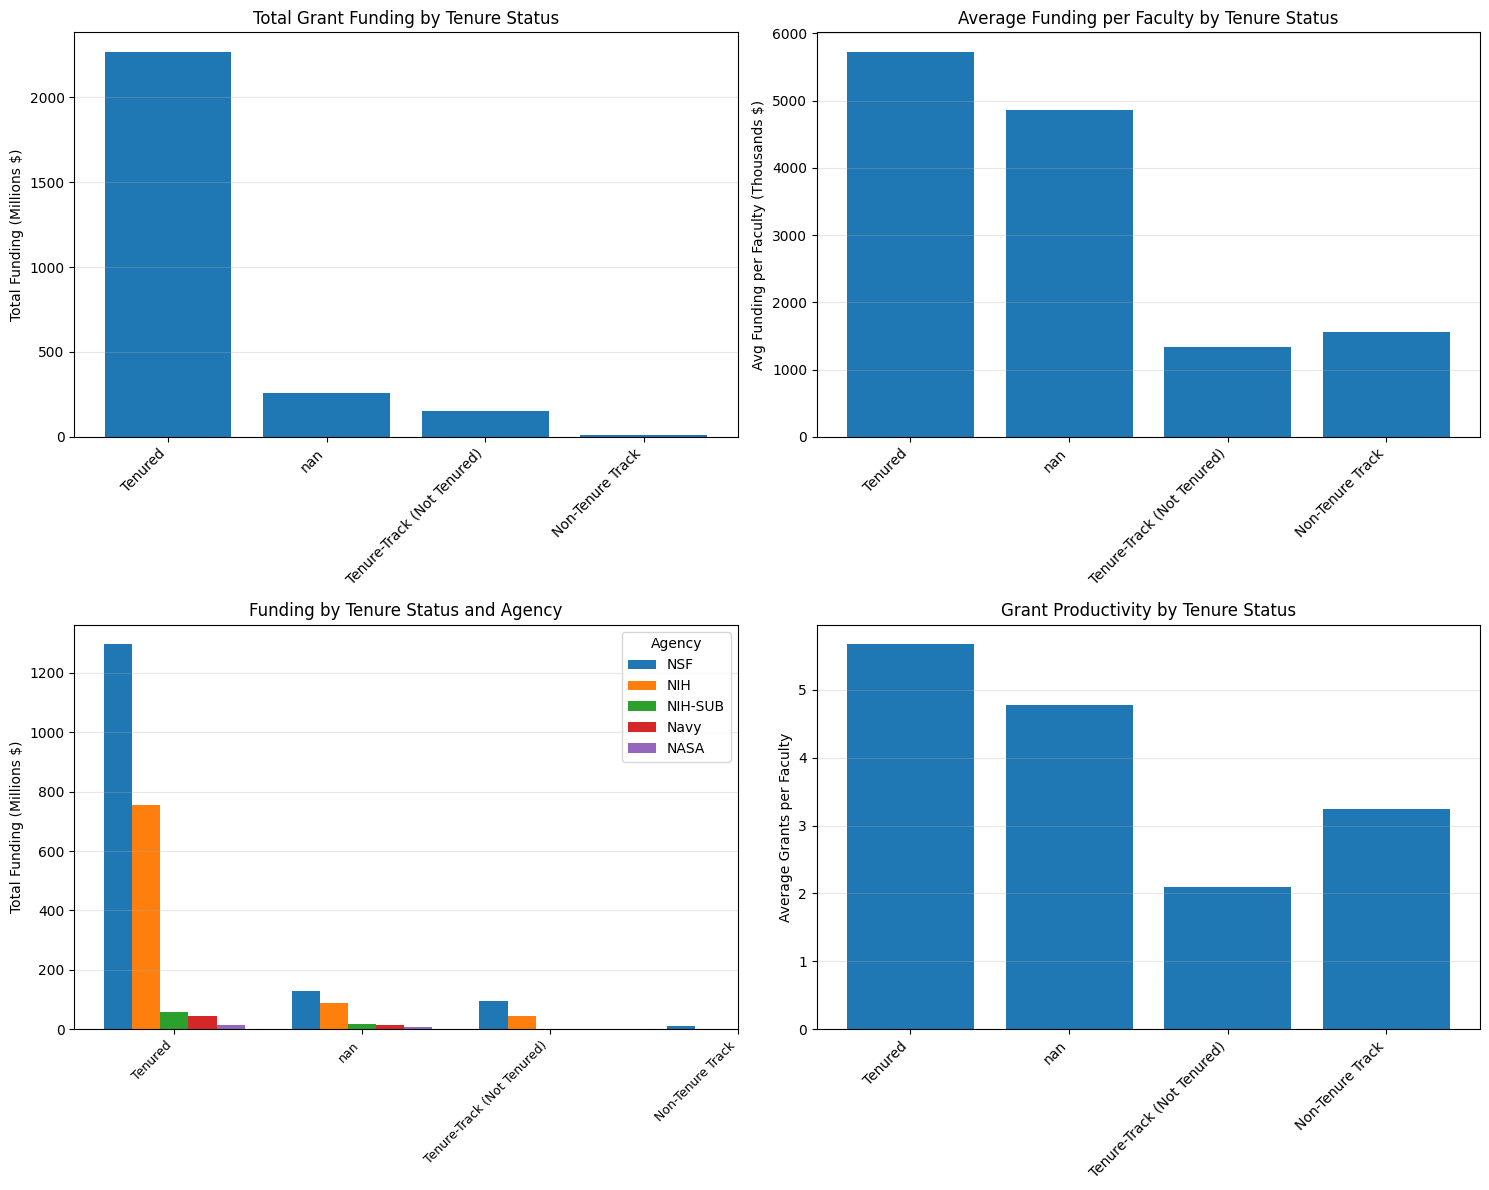

In [21]:
# Visualize tenure status funding patterns
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Total funding by tenure status
axes[0, 0].bar(range(len(tenure_overall)), tenure_overall['total_funding'] / 1e6)
axes[0, 0].set_xticks(range(len(tenure_overall)))
axes[0, 0].set_xticklabels(tenure_overall['tenure_category'], rotation=45, ha='right')
axes[0, 0].set_ylabel('Total Funding (Millions $)')
axes[0, 0].set_title('Total Grant Funding by Tenure Status')
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Average funding per faculty by tenure status
axes[0, 1].bar(range(len(tenure_overall)), tenure_overall['avg_funding_per_faculty'] / 1000)
axes[0, 1].set_xticks(range(len(tenure_overall)))
axes[0, 1].set_xticklabels(tenure_overall['tenure_category'], rotation=45, ha='right')
axes[0, 1].set_ylabel('Avg Funding per Faculty (Thousands $)')
axes[0, 1].set_title('Average Funding per Faculty by Tenure Status')
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Funding by tenure and agency (grouped bar)
for i, agency in enumerate(top_agencies):
    agency_data = tenure_agency_funding[tenure_agency_funding['agencycode'] == agency]
    x_pos = np.arange(len(agency_data)) + i * 0.15
    axes[1, 0].bar(x_pos, agency_data['total_funding'] / 1e6, width=0.15, label=agency)

axes[1, 0].set_xticks(np.arange(len(tenure_overall)) + 0.3)
axes[1, 0].set_xticklabels(tenure_overall['tenure_category'], rotation=45, ha='right', fontsize=9)
axes[1, 0].set_ylabel('Total Funding (Millions $)')
axes[1, 0].set_title('Funding by Tenure Status and Agency')
axes[1, 0].legend(title='Agency')
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Grant productivity by tenure status
axes[1, 1].bar(range(len(tenure_overall)), tenure_overall['avg_grants_per_faculty'])
axes[1, 1].set_xticks(range(len(tenure_overall)))
axes[1, 1].set_xticklabels(tenure_overall['tenure_category'], rotation=45, ha='right')
axes[1, 1].set_ylabel('Average Grants per Faculty')
axes[1, 1].set_title('Grant Productivity by Tenure Status')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(PROCESSED_DIR.parent / 'outputs' / 'tenure_funding_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

### Calculate number of grants that have abstracts available vs not available (ri_matches_grants_2026 vs grans_with_abstracts)

In [22]:
# Abstract coverage — abstract text now lives directly on grants.abstract
total_grants = grants['grant_id'].nunique()
has_abs = grants['abstract'].fillna('').astype(str).str.len() > 0
n_with = int(has_abs.sum())
n_without = total_grants - n_with

print(f"Total grants (from ri_matches): {total_grants:,}")
print(f"  With non-empty abstract   : {n_with:,} ({n_with/total_grants*100:.1f}%)")
print(f"  Without abstract          : {n_without:,} ({n_without/total_grants*100:.1f}%)\n")

# For context: the orphaned-abstracts table holds abstracts that did NOT match
# any NEU grant_id (external NSF/NIH crawl of collaborators + non-NU awards).
print(f"grant_orphaned_abstracts (kept separately for optional vocab enrichment):")
print(f"  Records                   : {len(grant_orphaned_abstracts):,}")
print(f"  With non-empty abstract   : {(grant_orphaned_abstracts['abstract'].fillna('').astype(str).str.len() > 0).sum():,}")

Total grants (from ri_matches): 2,676
  With non-empty abstract   : 1,936 (72.3%)
  Without abstract          : 740 (27.7%)

grant_orphaned_abstracts (kept separately for optional vocab enrichment):
  Records                   : 5,095
  With non-empty abstract   : 407


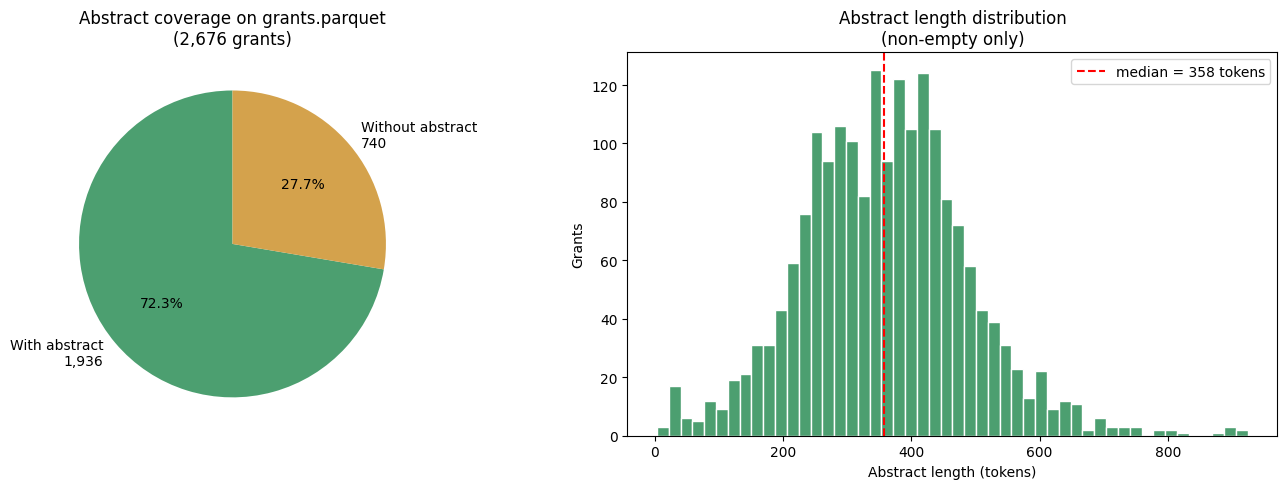


Of the 1,936 grants with abstract text:
  median length : 358 tokens
  mean length   : 359 tokens
  ≥ 40 tokens (usable for topic model): 1,916


In [23]:
# Visualize abstract coverage on grants
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: coverage pie
ax1.pie([n_with, n_without],
        labels=[f'With abstract\n{n_with:,}', f'Without abstract\n{n_without:,}'],
        colors=['#4C9F70', '#D4A24C'], autopct='%1.1f%%', startangle=90)
ax1.set_title(f'Abstract coverage on grants.parquet\n({total_grants:,} grants)')

# Right: length distribution among those with abstract text
lens = grants.loc[has_abs, 'abstract'].astype(str).str.split().str.len()
ax2.hist(lens, bins=50, color='#4C9F70', edgecolor='white')
ax2.axvline(lens.median(), color='red', linestyle='--',
            label=f'median = {int(lens.median())} tokens')
ax2.set_xlabel('Abstract length (tokens)')
ax2.set_ylabel('Grants')
ax2.set_title('Abstract length distribution\n(non-empty only)')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\nOf the {n_with:,} grants with abstract text:")
print(f"  median length : {int(lens.median())} tokens")
print(f"  mean length   : {int(lens.mean())} tokens")
print(f"  ≥ 40 tokens (usable for topic model): {(lens >= 40).sum():,}")

### Abstract availability by agency, period, and faculty

Abstract coverage is uneven across three dimensions — worth knowing before you
interpret anything the topic model produces:

- **Agency** — some funders (NIH after 2019) simply don't have abstracts in the
  internal export, so any topic that leans NIH will be under-counted in later years.
- **Period** — abstract upload compliance shifts over time.
- **Faculty** — a handful of PIs account for most grants, so their coverage
  disproportionately shapes the topic model's view.

Overall: 1,934/2,676 grants have abstract text (72.3%)

=== Abstract coverage by AGENCY (top 12) ===
                                                 n_grants  n_with_abs  total_dollars  pct_with_abs
agencyname                                                                                        
National Science Foundation                          1686        1531     1050914346          90.8
National Institutes of Health                         546         354      862873694          64.8
National Institutes of Health - SubAward              105           0       76214973           0.0
Office of Naval Research                               87           0       59689382           0.0
National Aeronautics and Space Administration          49          16       22056110          32.7
Army Research Office                                   48           0       13184426           0.0
Department Of Energy                                   37          14       33840043          37.8
Air Forc

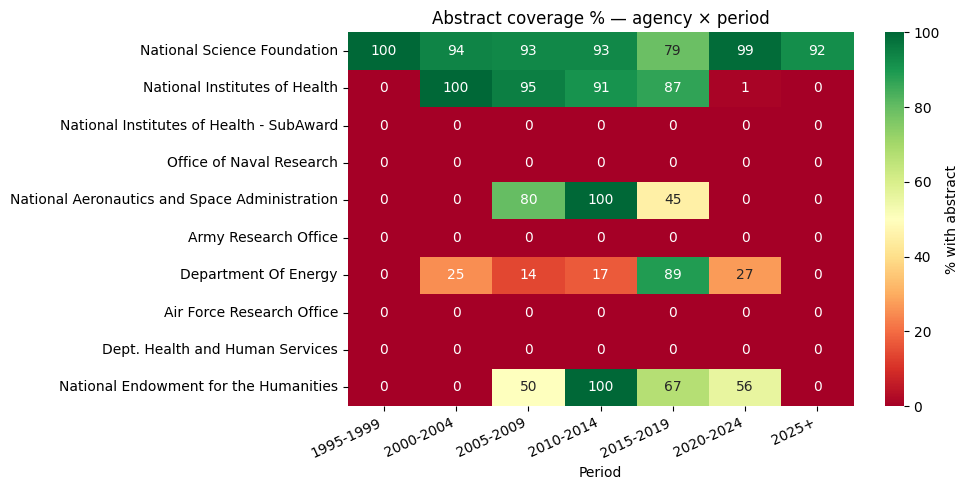

In [24]:
# Abstract availability diagnostic
# ---------------------------------
# For each dimension, we compute:  n_grants, n_with_abstract, coverage%
# Uses the current grants.parquet (abstract text merged in from grants-with-abstract).

_g = grants.copy()
_g['has_abs'] = _g['abstract'].astype(str).str.len() > 50
_total    = len(_g)
_total_ok = int(_g.has_abs.sum())
print(f'Overall: {_total_ok:,}/{_total:,} grants have abstract text ({_total_ok/_total*100:.1f}%)\n')

# ---- (1) By agency (top 12 by grant count) ----
agency_stats = (_g.groupby(_g['agencyname'].fillna('(unknown)'))
                  .agg(n_grants=('grant_id','count'),
                       n_with_abs=('has_abs','sum'),
                       total_dollars=('totaldollars','sum'))
                  .assign(pct_with_abs=lambda d: (d.n_with_abs/d.n_grants*100).round(1))
                  .sort_values('n_grants', ascending=False)
                  .head(12))
print('=== Abstract coverage by AGENCY (top 12) ===')
print(agency_stats.to_string())

# ---- (2) By period (5-year buckets on startdateyear) ----
_g['period'] = pd.cut(_g['startdateyear'],
                       bins=[1994, 1999, 2004, 2009, 2014, 2019, 2024, 2030],
                       labels=['1995-1999','2000-2004','2005-2009','2010-2014',
                               '2015-2019','2020-2024','2025+'])
period_stats = (_g.groupby('period', observed=True)
                  .agg(n_grants=('grant_id','count'),
                       n_with_abs=('has_abs','sum'))
                  .assign(pct_with_abs=lambda d: (d.n_with_abs/d.n_grants*100).round(1)))
print('\n=== Abstract coverage by PERIOD (5-year buckets) ===')
print(period_stats.to_string())

# ---- (2b) NIH-only view of the same buckets (the collapse is agency-specific) ----
_nih = _g[_g.agencyname.astype(str).str.contains('National Institutes of Health',
                                                   case=False, na=False)]
nih_period = (_nih.groupby('period', observed=True)
                  .agg(n_grants=('grant_id','count'),
                       n_with_abs=('has_abs','sum'))
                  .assign(pct_with_abs=lambda d: (d.n_with_abs/d.n_grants*100).round(1)))
print('\n=== NIH-only coverage by period (shows the 2020+ cliff) ===')
print(nih_period.to_string())

# ---- (3) By faculty — top 20 PIs by grant count ----
# Attach abstract flag through the faculty_grants join. is_pi==True to focus on lead PIs.
fac_pi = (faculty_grants[faculty_grants.is_pi == True]
          .merge(_g[['grant_id','has_abs']].astype({'grant_id':str}), on='grant_id', how='left'))
fac_pi['has_abs'] = fac_pi.has_abs.fillna(False)

faculty_stats = (fac_pi.groupby(['faculty_id','faculty_name'])
                    .agg(n_grants=('grant_id','nunique'),
                         n_with_abs=('has_abs','sum'))
                    .assign(pct_with_abs=lambda d: (d.n_with_abs/d.n_grants*100).round(0).astype(int))
                    .sort_values('n_grants', ascending=False)
                    .head(20)
                    .reset_index())
print('\n=== Abstract coverage — top 20 PIs by grant count (lead-PI only) ===')
print(faculty_stats[['faculty_name','n_grants','n_with_abs','pct_with_abs']].to_string(index=False))

# ---- (4) Agency × period — coverage matrix (top 10 agencies) ----
_top_ag = _g['agencyname'].value_counts().head(10).index
_ap = _g[_g['agencyname'].isin(_top_ag)]

# n_grants  and n_with_abs, both indexed by (agency, period)
_n   = _ap.groupby(['agencyname','period'], observed=True).grant_id.count().unstack(fill_value=0)
_wa  = _ap.groupby(['agencyname','period'], observed=True).has_abs.sum().unstack(fill_value=0)
_pct = (_wa / _n.replace(0, np.nan) * 100).round(0)

# Preserve original agency order (by total grants desc)
_pct = _pct.reindex(_top_ag)
_n   = _n.reindex(_top_ag)

# Print an aligned "pct% (n)" table so both signals are visible in one glance
print('\n=== AGENCY x PERIOD — abstract coverage % (n grants in parentheses) ===')
def _fmt(pct, n):
    if pd.isna(pct): return '   -   '
    return f'{int(pct):3d}% ({int(n):>3d})'
matrix = pd.DataFrame({col: [_fmt(_pct.loc[a, col], _n.loc[a, col]) for a in _pct.index]
                        for col in _pct.columns},
                       index=_pct.index)
with pd.option_context('display.max_colwidth', None, 'display.width', 200):
    print(matrix.to_string())

# And a quick heatmap
import matplotlib.pyplot as plt
import seaborn as sns
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(_pct.fillna(0), annot=True, fmt='.0f', cmap='RdYlGn', vmin=0, vmax=100,
            cbar_kws={'label': '% with abstract'}, ax=ax)
ax.set_title('Abstract coverage % — agency × period')
ax.set_xlabel('Period'); ax.set_ylabel('')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()